In [1]:
import numpy as np

path = "../../output/protenn2/v5"

In [2]:

import json
import os.path
import pickle

import torch
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader

from src.protenn2.analysis.inference import run_inference
from src.protenn2.utils import get_train_val_test_paths, get_device, call_domains_list

# get file paths

log_path = os.path.join(path, "log")

label_encoder_path = os.path.join(path, "label_encoder.pkl")
model_path = os.path.join(path, "best_model.pt")
with open(os.path.join(path, "params.json"), "r") as f:
    params = json.load(f)
if "input_folder" not in params:
    raise ValueError("input_folder must be specified")
dataset_path = os.path.join("../../", params["input_folder"])
train_path, val_path, test_path = get_train_val_test_paths(dataset_path)

from src.protenn2.utils import calculate_max_protein_length
from src.protenn2.dataset import CathPredPerResidueDataset, create_protein_collate_fn
from src.protenn2.model import CathPredEnn2

# Initialize objects

device = get_device()
with open(label_encoder_path, "rb") as f:
    label_encoder: LabelEncoder = pickle.load(f)
num_classes = len(label_encoder.classes_)
max_protein_length = calculate_max_protein_length(dataset_path)

model = CathPredEnn2(num_classes=num_classes)
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
val_dataset = CathPredPerResidueDataset(val_path, label_encoder=label_encoder,
                                        embedding_dir="../../data/embeddings/protein_embeddings_new")

collate_fn = create_protein_collate_fn(max_protein_length, val_dataset.padding_encoded_id)

val_dataloader = DataLoader(val_dataset, collate_fn=collate_fn)

y_true_labels_list, y_pred_confidences_list, protein_chain_id_list = run_inference(model=model,
                                                                                   dataloader=val_dataloader,
                                                                                   padding_encoded_id=val_dataset.padding_encoded_id,
                                                                                   device=device,
                                                                                   return_protein_chain_id=True)

Using MPS (Apple Silicon GPU).
Max protein length: 599
Dataset initialized with 1319 unique proteins.
Running inference on 1319 proteins...


Inference Progress:  22%|██▏       | 284/1319 [00:01<00:03, 260.87it/s]

Inference Progress: 100%|██████████| 1319/1319 [00:05<00:00, 244.70it/s]

Inference complete. Processed 1319 proteins


In [3]:
post_process_kwargs = {"reporting_threshold": 0.1, "region_min_length": 20, "gaussian_sigma": 2}



In [4]:
import importlib
import utils
importlib.reload(utils)

y_pred_labels_list_post = utils.call_domains_list(confidences_list=y_pred_confidences_list,
                                            no_domain_label_id=val_dataset.no_domain_encoded_id, **post_process_kwargs)








In [5]:
y_pred_labels_list = [np.argmax(confidences, axis=-1) for confidences in y_pred_confidences_list]

In [6]:
y_pred_labels_list

[array([877, 877, 877, 877, 877, 877, 877, 877, 877, 877, 877,  41, 877,
        877, 877,  41,  41,  41,  41,  41, 877, 877, 877, 877, 877, 877,
        877, 877, 877, 877, 877, 877, 877, 877, 877, 877, 877, 877, 877,
        877, 877,  29, 877,  29, 877, 877, 877, 877, 877, 877, 877, 877,
        877, 877, 877, 877, 877, 877, 877, 877, 877, 877, 877,  41, 877,
        877, 877, 877, 877, 877, 877, 877, 877, 877, 877, 877, 877, 877,
        877, 877, 877, 877, 877, 877, 877, 877, 877, 877, 877, 877, 877,
        877, 776, 877, 877, 877, 877, 877, 877, 877, 877, 877, 877, 877,
        877, 877, 877, 877, 877, 877, 877, 877, 877, 877, 877, 877, 877,
        877, 107, 107, 877, 107, 107, 877, 877, 107, 107, 107, 877, 877,
        877, 877, 107, 107, 107, 877, 877, 877, 877, 877, 877, 877, 877,
        877, 877, 107, 107, 107, 107, 107, 107, 107, 107, 107, 107, 107,
        107, 107, 877, 107, 107, 107, 877, 107, 107, 107, 877, 877, 877,
        877, 877, 877, 877, 877, 877, 877, 877, 877

In [7]:
def encoded_to_decoded(labels_list):
    return [label_encoder.inverse_transform(label) for label in labels_list]


true_labels_list_cath, pred_labels_list_cath, pred_labels_list_post_cath = encoded_to_decoded(
    y_true_labels_list), encoded_to_decoded(y_pred_labels_list), encoded_to_decoded(y_pred_labels_list_post)
data = list(zip(true_labels_list_cath, y_pred_confidences_list, pred_labels_list_post_cath, protein_chain_id_list))

In [8]:

# import src.protenn2.analysis.sample_vizualization as analysis
#
# data = list(zip(true_labels_list_cath, y_pred_confidences_list, pred_labels_list_post_cath, protein_chain_id_list))
#
# problematic_chains = {}
# for true_labels_cath, y_pred_confidences, pred_labels_post_cath, protein_chain_id in data:
#     if protein_chain_id not in ("1egiA", "1ev0A"):
#         continue
#     problematic_chains[protein_chain_id] = {"true_labels_cath": true_labels_cath,
#                                             "y_pred_confidences": y_pred_confidences}
# label = label_encoder.transform(["3.10.100.10"])
# print(label)
# for confidence in problematic_chains["1egiA"]["y_pred_confidences"]:
#     print(confidence[label])
#     import importlib
# importlib.reload(utils)
#
# confidences = problematic_chains["1egiA"]["y_pred_confidences"]
# labels = utils.call_domains(confidences=confidences, no_domain_label_id=label_encoder.transform(["NO_DOMAIN_REGION"])[0],**post_process_kwargs)

Generating visualizations:   0%|          | 0/1319 [00:00<?, ?it/s]/var/folders/nf/_hy8vffs4dzc3cfg063rfz0w0000gn/T/ipykernel_47462/4127535330.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
Generating visualizations: 100%|██████████| 1319/1319 [00:04<00:00, 311.11it/s]


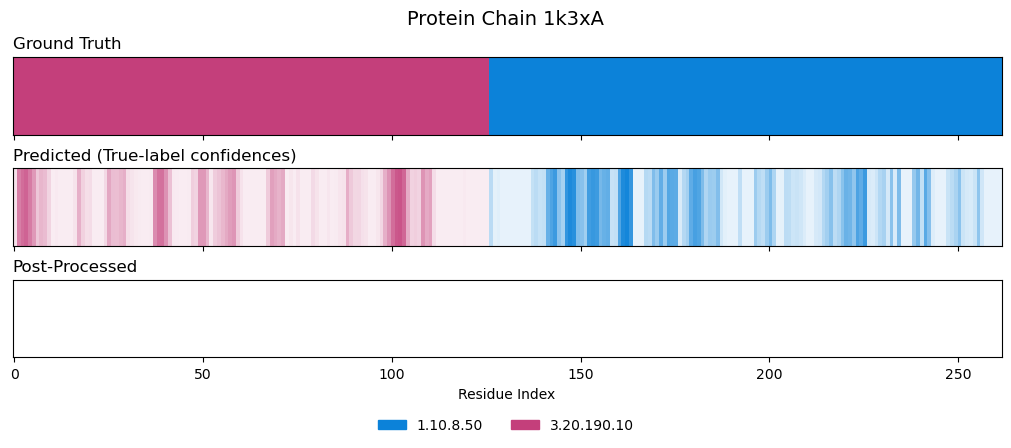

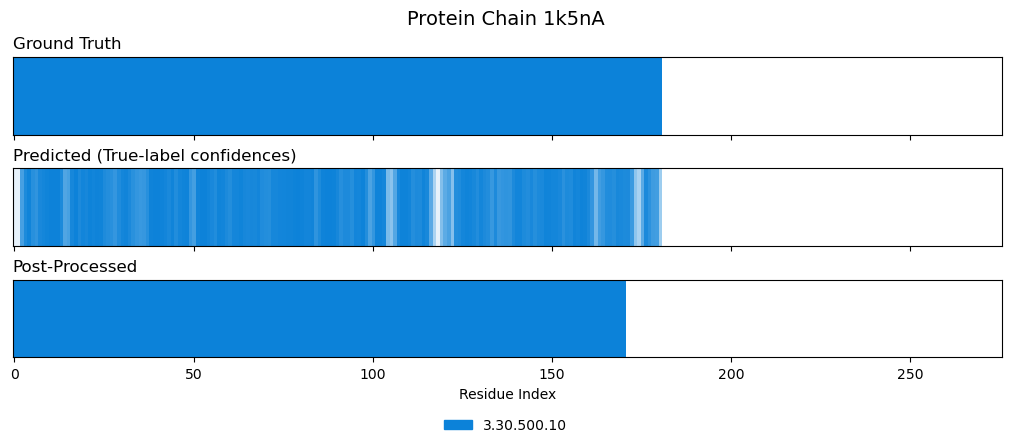

In [13]:
import src.protenn2.analysis.sample_vizualization as analysis
from matplotlib import pyplot as plt
from tqdm import tqdm
import importlib

importlib.reload(analysis)
output_path = os.path.join(path, "protein_chain_vizualization")
os.makedirs(output_path, exist_ok=True)

for true_labels_cath, y_pred_confidences, pred_labels_post_cath, protein_chain_id in tqdm(data,
                                                                                          desc="Generating visualizations"):
    if protein_chain_id not in ("1k3xA", "1k5nA"):
        continue
    fig = analysis.visualize_prediction_sample_only_true(
        true_labels_cath,
        y_pred_confidences,
        pred_labels_post_cath,
        label_encoder=label_encoder,
        protein_chain_id=protein_chain_id
    )

    fig.savefig(os.path.join(output_path, protein_chain_id + ".png"), bbox_inches="tight", dpi=1000)
    fig.show()
    # plt.close(fig)  # Close to avoid memory accumulation